<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/FlyRank_Content_Refresh_Recommendation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank — Content Refresh Recommendation Engine (DuckDB)

For each client-content pair, generate:
- **Priority score and tier** (HIGH / MEDIUM / LOW)
- **Why recommended** — evidence-based reasons from traffic trends, demand, and search position
- **Suggested action** — a practical next step
- **Evidence metrics** — so the recommendation is auditable

## Important scope note
The warehouse has daily performance and 90-day query-level signals. Unless the content dimension includes a reliable publication/update date, this notebook cannot truthfully claim an article is old. It inspects the schema and uses an age signal only if a suitable date column is available. Similarly, query impressions are a demand proxy, not total market search volume.

This first version is a **transparent rules-based recommendation engine**, not a trained model. No verified historical refresh outcomes have been provided, so a supervised recommender would have no defensible target yet. The scoring weights are explicit hypotheses to validate with editors and future refresh results.

In [ ]:
%pip -q install duckdb huggingface_hub pandas numpy matplotlib seaborn

## 1. Authenticate to Hugging Face

In Colab, add `HF_TOKEN` under Secrets and enable notebook access. The fallback uses a hidden prompt. Do not hard-code or share your token.

In [ ]:
import os
from getpass import getpass

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = None
if not HF_TOKEN:
    HF_TOKEN = getpass("Hugging Face token (input hidden): ")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN is required.")

Hugging Face token (input hidden): ··········


In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{safe_token}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}
print("DuckDB connection ready.")

DuckDB connection ready.


## 2. Inspect available content metadata

We inspect the dimension schema rather than assuming publication date, last-updated date, title, or URL columns exist. These fields will be used only if found and suitable.

In [ ]:
content_schema = con.execute(f"DESCRIBE SELECT * FROM {TABLES['dim_content']}").df()
display(content_schema)
content_columns = content_schema["column_name"].tolist()
print("Available content dimension columns:")
print(content_columns)

,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None


Available content dimension columns:
['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']


## 3. Aggregate performance and search-demand signals in DuckDB

Features include recent vs previous 30-day impressions/clicks, CTR, average position, ranking volatility, and 90-day query-mix signals. The SQL pushes the large-table aggregation into DuckDB before materializing the smaller result in Python.

In [ ]:
recommendation_sql = f'''
WITH bounds AS (
    SELECT MAX(report_date) AS end_d FROM {TABLES["fact_daily"]}
),
daily AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_last30,
        SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_prev30,
        SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clk_last30,
        SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clk_prev30,
        AVG(CASE WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                 THEN f.gsc_avg_position END) AS pos_last30,
        AVG(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                  AND f.report_date > b.end_d - INTERVAL 60 DAY
                 THEN f.gsc_avg_position END) AS pos_prev30,
        STDDEV_SAMP(f.gsc_avg_position) AS pos_volatility_60d,
        MAX(b.end_d) AS data_end_date
    FROM {TABLES["fact_daily"]} f
    CROSS JOIN bounds b
    WHERE f.report_date > b.end_d - INTERVAL 60 DAY
    GROUP BY f.client_hash_id, f.content_hash_id
    HAVING SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                     AND f.report_date > b.end_d - INTERVAL 60 DAY
                    THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) >= 20
),
qsignals AS (
    SELECT
        content_hash_id,
        ANY_VALUE(content_visible_query_count) AS visible_queries,
        ANY_VALUE(rare_impressions_share) AS rare_share,
        ANY_VALUE(anonymized_impressions_share) AS anon_share,
        MAX(impressions_90d) AS top_query_impressions,
        SUM(impressions_90d) AS kept_query_impressions
    FROM {TABLES["fact_query_90d"]}
    GROUP BY content_hash_id
)
SELECT d.*,
       (d.imp_last30 - d.imp_prev30) / NULLIF(d.imp_prev30, 0) AS trend_pct,
       d.clk_last30 / NULLIF(d.imp_last30, 0) AS ctr_last30,
       d.clk_prev30 / NULLIF(d.imp_prev30, 0) AS ctr_prev30,
       d.pos_last30 - d.pos_prev30 AS position_change,
       q.visible_queries,
       q.rare_share,
       q.anon_share,
       q.top_query_impressions,
       q.kept_query_impressions,
       q.top_query_impressions / NULLIF(q.kept_query_impressions, 0) AS top_query_share
FROM daily d
LEFT JOIN qsignals q ON d.content_hash_id = q.content_hash_id
'''
performance = con.execute(recommendation_sql).df()
print(f"Client-content rows: {len(performance):,}")
display(performance.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Client-content rows: 157,464


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,pos_volatility_60d,data_end_date,trend_pct,ctr_last30,ctr_prev30,position_change,visible_queries,rare_share,anon_share,top_query_impressions,kept_query_impressions,top_query_share
0,client_08a6a72ff48e62c0,content_5f6c0644690c7bda,34.0,92.0,0.0,0.0,32.229167,18.085009,15.303829,2026-06-30,-0.630435,0.000000,0.000000,14.144158,4,0.231834,0.598616,16,49.0,0.326531
1,client_08a6a72ff48e62c0,content_5f6f16f9f290ff0b,19.0,175.0,0.0,0.0,42.761905,28.933359,28.814222,2026-06-30,-0.891429,0.000000,0.000000,13.828546,3,0.196429,0.553571,46,70.0,0.657143
2,client_08a6a72ff48e62c0,content_5f7bba49f47a5348,6.0,160.0,0.0,1.0,55.700000,14.966195,29.239835,2026-06-30,-0.962500,0.000000,0.006250,40.733805,6,0.144472,0.556533,85,238.0,0.357143
3,client_08a6a72ff48e62c0,content_5f935fbc1bbca626,140.0,4685.0,4.0,18.0,11.899650,14.502749,15.288859,2026-06-30,-0.970117,0.028571,0.003842,-2.603099,3,0.154762,0.741071,14,35.0,0.400000
4,client_08a6a72ff48e62c0,content_5f9d4ddd5a2d2e21,22.0,60.0,0.0,0.0,58.338435,55.925000,24.613457,2026-06-30,-0.633333,0.000000,0.000000,2.413435,2,0.280488,0.109756,31,50.0,0.620000


## 4. Attach optional content metadata

This step looks for a content identifier plus likely URL/title and date fields. If the schema has multiple candidates, it uses the first matching candidate and prints the selection. If no reliable update/publication date is found, age will be unavailable and will not influence the score.

In [ ]:
# Candidate names are matched case-insensitively; actual column names come from the inspected schema.
lower_to_actual = {c.lower(): c for c in content_columns}

def first_existing(candidates):
    for name in candidates:
        if name.lower() in lower_to_actual:
            return lower_to_actual[name.lower()]
    return None

content_key = first_existing(["content_hash_id"])
title_col = first_existing(["title", "content_title", "page_title", "meta_title"])
url_col = first_existing(["url", "canonical_url", "page_url", "content_url"])
date_col = first_existing(["last_updated_at", "updated_at", "last_modified", "modified_at",
                           "published_at", "publication_date", "created_at", "published_date"])

print("Join key:", content_key)
print("Title field:", title_col)
print("URL field:", url_col)
print("Potential age/date field:", date_col)

if content_key is None:
    print("No content_hash_id in dim_content; recommendations will use performance data only.")
    recs = performance.copy()
else:
    selected = [content_key]
    if title_col: selected.append(title_col)
    if url_col and url_col not in selected: selected.append(url_col)
    if date_col and date_col not in selected: selected.append(date_col)
    projection = ", ".join([f'"{c}"' for c in selected])
    meta = con.execute(f"SELECT {projection} FROM {TABLES['dim_content']}").df()
    rename = {content_key: "content_hash_id"}
    if title_col: rename[title_col] = "content_title"
    if url_col: rename[url_col] = "content_url"
    if date_col: rename[date_col] = "content_date_metadata"
    meta = meta.rename(columns=rename).drop_duplicates(subset=["content_hash_id"])
    recs = performance.merge(meta, on="content_hash_id", how="left")

if "content_title" not in recs.columns: recs["content_title"] = pd.NA
if "content_url" not in recs.columns: recs["content_url"] = pd.NA
if "content_date_metadata" not in recs.columns: recs["content_date_metadata"] = pd.NaT

recs["content_date_metadata"] = pd.to_datetime(recs["content_date_metadata"], errors="coerce", utc=True)
recs["data_end_date"] = pd.to_datetime(recs["data_end_date"], errors="coerce", utc=True)
recs["content_age_days"] = (recs["data_end_date"] - recs["content_date_metadata"]).dt.days
# Use age only for plausible non-negative ages. Future or malformed dates are ignored.
recs.loc[(recs["content_age_days"] < 0) | (recs["content_age_days"] > 10000), "content_age_days"] = np.nan
print("Rows after metadata join:", f"{len(recs):,}")
print("Rows with usable content age:", f"{recs['content_age_days'].notna().sum():,}")
display(recs[["client_hash_id","content_hash_id","content_title","content_url","content_age_days"]].head())

Join key: content_hash_id
Title field: None
URL field: None
Potential age/date field: None
Rows after metadata join: 157,464
Rows with usable content age: 0


,client_hash_id,content_hash_id,content_title,content_url,content_age_days
0,client_08a6a72ff48e62c0,content_5f6c0644690c7bda,<NA>,<NA>,NaN
1,client_08a6a72ff48e62c0,content_5f6f16f9f290ff0b,<NA>,<NA>,NaN
2,client_08a6a72ff48e62c0,content_5f7bba49f47a5348,<NA>,<NA>,NaN
3,client_08a6a72ff48e62c0,content_5f935fbc1bbca626,<NA>,<NA>,NaN
4,client_08a6a72ff48e62c0,content_5f9d4ddd5a2d2e21,<NA>,<NA>,NaN


## 5. Build transparent recommendation signals

We score each article on four dimensions:
1. **Decline severity** — negative recent impression trend.
2. **Search demand / opportunity** — recent and prior impressions plus visible query count.
3. **Page-one opportunity** — average position between 4 and 20, where a content improvement may be worth investigating.
4. **Content age** — only if a usable date column exists in the content dimension.

The weights are an initial business hypothesis. The score is a prioritization heuristic, not a calibrated probability of traffic recovery.

In [ ]:
# 1) Decline severity: map trend_pct into 0..1
trend = recs["trend_pct"].replace([np.inf, -np.inf], np.nan)
recs["decline_signal"] = ((-trend - 0.05) / 0.75).clip(0, 1).fillna(0)

# 2) Demand signal: relative within the current dataset, using log scale to reduce skew
log_impressions = np.log1p(recs[["imp_last30", "imp_prev30"]].clip(lower=0).max(axis=1))
def percentile_rank(s):
    s = pd.to_numeric(s, errors="coerce")
    return s.rank(pct=True).fillna(0)
recs["demand_signal"] = percentile_rank(log_impressions)

visible_queries = pd.to_numeric(recs["visible_queries"], errors="coerce")
recs["query_coverage_signal"] = percentile_rank(np.log1p(visible_queries.clip(lower=0)))

# 3) Ranking opportunity: strongest for positions roughly 4-20, weaker outside
pos = pd.to_numeric(recs["pos_last30"], errors="coerce")
recs["page_one_opportunity_signal"] = np.select(
    [(pos >= 4) & (pos <= 10), (pos > 10) & (pos <= 20), (pos > 20) & (pos <= 30), (pos > 0) & (pos < 4)],
    [1.0, 0.8, 0.45, 0.35],
    default=0.0
)
recs.loc[pos.isna(), "page_one_opportunity_signal"] = 0.0

# 4) Age signal: 1 when >= 730 days, 0 at <= 90 days; linear between.
age = pd.to_numeric(recs["content_age_days"], errors="coerce")
recs["age_signal"] = ((age - 90) / (730 - 90)).clip(0, 1)
recs["age_signal_available"] = age.notna()

# If no age metadata is available, remove age from the weighted score and renormalize.
base_weights = {
    "decline_signal": 0.40,
    "demand_signal": 0.25,
    "page_one_opportunity_signal": 0.25,
    "age_signal": 0.10
}
weighted_sum = (
    base_weights["decline_signal"] * recs["decline_signal"] +
    base_weights["demand_signal"] * recs["demand_signal"] +
    base_weights["page_one_opportunity_signal"] * recs["page_one_opportunity_signal"] +
    base_weights["age_signal"] * recs["age_signal"].fillna(0)
)
available_weight = (
    base_weights["decline_signal"] + base_weights["demand_signal"] +
    base_weights["page_one_opportunity_signal"] +
    base_weights["age_signal"] * recs["age_signal_available"].astype(float)
)
recs["priority_score"] = (100 * weighted_sum / available_weight).round(1)

recs["priority_tier"] = np.select(
    [recs["priority_score"] >= 70, recs["priority_score"] >= 45],
    ["HIGH", "MEDIUM"], default="LOW"
)
display(recs["priority_tier"].value_counts().to_frame("articles"))

,articles
priority_tier,
MEDIUM,70718
LOW,55114
HIGH,31632


## 6. Generate reasons and recommended actions

Reasons are assembled from observed signals. They explain why an article received its score, rather than merely returning a priority label.

In [ ]:
high_impression_threshold = recs[["imp_last30", "imp_prev30"]].max(axis=1).quantile(0.75)
high_query_threshold = pd.to_numeric(recs["visible_queries"], errors="coerce").quantile(0.75)

def build_reasons(row):
    reasons = []
    t = row.get("trend_pct")
    if pd.notna(t):
        if t <= -0.50: reasons.append(f"Impressions fell {abs(t):.0%} vs previous 30 days")
        elif t <= -0.20: reasons.append(f"Impressions declined {abs(t):.0%} vs previous 30 days")
        elif t < -0.05: reasons.append("Impressions show a mild decline")
    if pd.notna(row.get("imp_last30")) and pd.notna(row.get("imp_prev30")):
        if max(row["imp_last30"], row["imp_prev30"]) >= high_impression_threshold:
            reasons.append("Relatively high impression volume in this dataset")
    p = row.get("pos_last30")
    if pd.notna(p):
        if 4 <= p <= 10: reasons.append(f"Ranking near page-one boundary (average position {p:.1f})")
        elif 10 < p <= 20: reasons.append(f"Page-two opportunity (average position {p:.1f})")
    q = row.get("visible_queries")
    if pd.notna(q) and q >= high_query_threshold:
        reasons.append("Broad visible query coverage")
    age_days = row.get("content_age_days")
    if pd.notna(age_days) and age_days >= 730:
        reasons.append(f"Content metadata date is about {age_days/365:.1f} years old")
    if not reasons:
        reasons.append("No single strong signal; review trend, rankings, and query coverage")
    return reasons

def suggest_action(row):
    actions = []
    t, p = row.get("trend_pct"), row.get("pos_last30")
    if pd.notna(t) and t <= -0.20:
        actions.append("Audit search intent, SERP changes, internal links, and content freshness")
    if pd.notna(p) and 4 <= p <= 20:
        actions.append("Improve title/meta description, answer coverage, and on-page relevance")
    if pd.notna(row.get("content_age_days")) and row["content_age_days"] >= 730:
        actions.append("Verify facts, dates, examples, and outdated references")
    if pd.notna(row.get("ctr_last30")) and pd.notna(row.get("pos_last30")):
        if row["pos_last30"] <= 10 and row["ctr_last30"] < row.get("ctr_prev30", np.nan):
            actions.append("Investigate CTR decline; test title/snippet improvements")
    if not actions:
        actions.append("Review the evidence manually before scheduling a refresh")
    return actions

recs["reasons"] = recs.apply(build_reasons, axis=1)
recs["recommended_actions"] = recs.apply(suggest_action, axis=1)
recs["reasons_text"] = recs["reasons"].apply(lambda xs: " | ".join(xs))
recs["actions_text"] = recs["recommended_actions"].apply(lambda xs: " | ".join(xs))
recs["refresh_recommendation"] = np.select(
    [recs["priority_tier"].eq("HIGH"), recs["priority_tier"].eq("MEDIUM")],
    ["Review for refresh soon", "Add to refresh review backlog"],
    default="Monitor; refresh only if other evidence supports it"
)


## 7. Inspect the highest-priority recommendations

The table shows the score, tier, reasons, suggested actions, and evidence metrics. Treat the priority score as a ranking aid, not a probability.

In [ ]:
recs["priority_rank"] = recs.groupby("client_hash_id")["priority_score"].rank(method="first", ascending=False).astype(int)
columns_to_show = [
    "client_hash_id","content_hash_id","content_title","content_url",
    "priority_rank","priority_score","priority_tier","refresh_recommendation",
    "reasons_text","actions_text","trend_pct","imp_last30","imp_prev30",
    "clk_last30","clk_prev30","ctr_last30","ctr_prev30","pos_last30",
    "position_change","visible_queries","content_age_days"
]
columns_to_show = [c for c in columns_to_show if c in recs.columns]
tier_order = pd.CategoricalDtype(["HIGH", "MEDIUM", "LOW"], ordered=True)
recs["priority_tier"] = recs["priority_tier"].astype(tier_order)
display(recs.sort_values(["priority_tier","priority_score"],ascending=[True,False])[columns_to_show].head(100))

,client_hash_id,content_hash_id,content_title,content_url,priority_rank,priority_score,priority_tier,refresh_recommendation,reasons_text,actions_text,...,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,ctr_prev30,pos_last30,position_change,visible_queries,content_age_days
39324,client_73cda7b4e4f265ea,content_425715547c6a3ea8,<NA>,<NA>,1,100.0,HIGH,Review for refresh soon,Impressions fell 87% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,8020.0,63808.0,0.0,3.0,0.000000,0.000047,9.789446,1.259804,11,NaN
82940,client_3f0ce4d44fe94f3d,content_f79972e4438a9a03,<NA>,<NA>,1,100.0,HIGH,Review for refresh soon,Impressions fell 92% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,5790.0,70775.0,11.0,26.0,0.001900,0.000367,8.802433,-0.418489,236,NaN
84632,client_157ffe4d4a595515,content_9648c4d1595a0794,<NA>,<NA>,1,100.0,HIGH,Review for refresh soon,Impressions fell 97% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,6001.0,213610.0,12.0,52.0,0.002000,0.000243,4.520348,1.977273,464,NaN
103477,client_73cda7b4e4f265ea,content_9610ee5585b7a7fc,<NA>,<NA>,2,100.0,HIGH,Review for refresh soon,Impressions fell 85% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,12572.0,83715.0,4.0,8.0,0.000318,0.000096,9.646745,-0.000899,53,NaN
20394,client_62f4a7e64f5e0096,content_88ff1c6680db0a45,<NA>,<NA>,1,99.9,HIGH,Review for refresh soon,Impressions fell 81% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,11396.0,58473.0,5.0,2.0,0.000439,0.000034,9.710440,-0.513924,260,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112599,client_8ddc46da5414ffd8,content_d50c24b7896e36b7,<NA>,<NA>,9,98.8,HIGH,Review for refresh soon,Impressions fell 89% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,1035.0,9043.0,3.0,5.0,0.002899,0.000553,7.186594,-2.825068,21,NaN
2591,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,<NA>,<NA>,5,98.7,HIGH,Review for refresh soon,Impressions fell 78% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,48447.0,218715.0,146.0,1921.0,0.003014,0.008783,9.494924,3.625961,607,NaN
8897,client_20259bd6705d81d4,content_37d604ce47631462,<NA>,<NA>,3,98.7,HIGH,Review for refresh soon,Impressions fell 89% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,910.0,8329.0,21.0,44.0,0.023077,0.005283,8.926344,-0.732984,12,NaN
27302,client_62f4a7e64f5e0096,content_96863e1cd4903ef1,<NA>,<NA>,23,98.7,HIGH,Review for refresh soon,Impressions fell 93% vs previous 30 days | Rel...,"Audit search intent, SERP changes, internal li...",...,609.0,8553.0,4.0,18.0,0.006568,0.002105,8.687472,2.348893,46,NaN


## 8. Visualize the recommendation queue

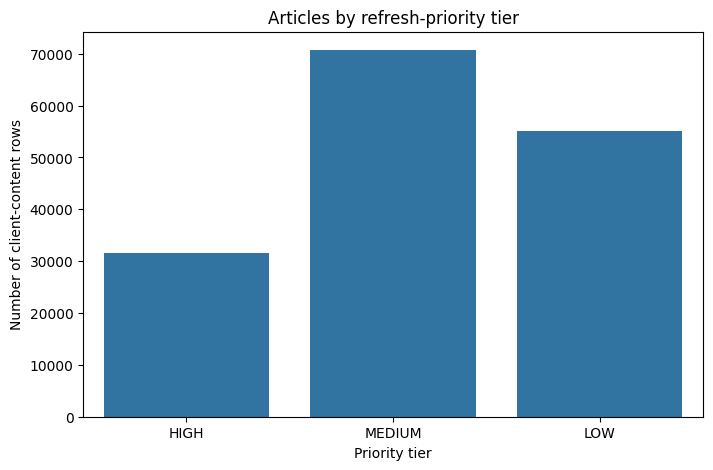

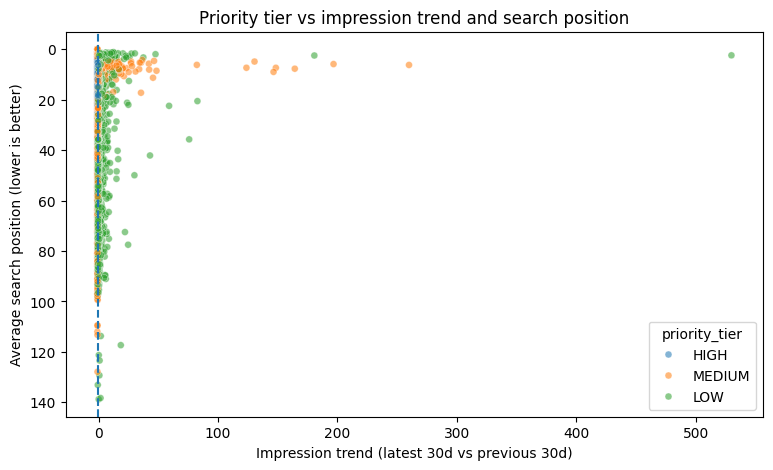

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=recs, x="priority_tier", order=["HIGH","MEDIUM","LOW"])
plt.title("Articles by refresh-priority tier")
plt.xlabel("Priority tier")
plt.ylabel("Number of client-content rows")
plt.show()

plt.figure(figsize=(9,5))
sns.scatterplot(data=recs.sample(min(len(recs), 20000), random_state=42),
                x="trend_pct", y="pos_last30", hue="priority_tier",
                alpha=.55, s=25)
plt.axvline(-0.20, linestyle="--")
plt.gca().invert_yaxis()
plt.title("Priority tier vs impression trend and search position")
plt.xlabel("Impression trend (latest 30d vs previous 30d)")
plt.ylabel("Average search position (lower is better)")
plt.show()

## 9. Export recommendations

The CSV is designed for editorial review and includes both machine-readable metrics and human-readable explanations.

In [ ]:
OUT_ALL = "flyrank_content_refresh_recommendations.csv"
OUT_HIGH = "flyrank_content_refresh_high_priority.csv"
OUT_REASON_SUMMARY = "flyrank_refresh_reason_summary.csv"

export_cols = [c for c in [
    "client_hash_id","content_hash_id","content_title","content_url",
    "priority_rank","priority_score","priority_tier","refresh_recommendation",
    "reasons_text","actions_text","trend_pct","imp_last30","imp_prev30",
    "clk_last30","clk_prev30","ctr_last30","ctr_prev30","pos_last30",
    "pos_prev30","position_change","pos_volatility_60d","visible_queries",
    "rare_share","anon_share","top_query_share","content_age_days"
] if c in recs.columns]

recs.sort_values(["priority_tier","priority_score"], ascending=[True,False])[export_cols].to_csv(OUT_ALL,index=False)
recs.loc[recs["priority_tier"].eq("HIGH")].sort_values("priority_score",ascending=False)[export_cols].to_csv(OUT_HIGH,index=False)

reason_summary = (
    recs[["reasons"]].explode("reasons")
        .groupby("reasons", dropna=False).size()
        .sort_values(ascending=False).rename("article_count").to_frame()
)
reason_summary.to_csv(OUT_REASON_SUMMARY)
print("Saved:", OUT_ALL, OUT_HIGH, OUT_REASON_SUMMARY)

try:
    from google.colab import files as colab_files
    for filename in [OUT_ALL, OUT_HIGH, OUT_REASON_SUMMARY]:
        colab_files.download(filename)
except Exception as exc:
    print("Automatic browser downloads unavailable in this environment:", exc)

## 10. How to turn this into a production recommender

1. Have editors review recommendations and record whether each article was refreshed, why, and the date.
2. Track post-refresh outcomes against a comparable baseline (impressions, clicks, conversions, and revenue where available).
3. Add editorial review labels and post-refresh uplift as future training targets.
4. Replace heuristic weights with validated learned ranking once outcomes exist.
5. Add safeguards for seasonality, indexing problems, technical SEO, cannibalization, and low-data pages.
6. Treat age as unknown if the warehouse does not contain a reliable publication/update date.

**Current limitations:** The priority score is rule-based; “search demand” is approximated by observed impressions and visible queries; “old content” is only used if a reliable date column exists. The notebook does not claim causal lift or guaranteed traffic recovery.